In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

BOLD_COLS = [f"ts_{k}" for k in range(720)]

In [34]:
data = pd.read_csv("processed_data.csv")
data.head()

,subject,ROI,NumVert,SurfArea_mm2,GrayVol_mm3,ThickAvg_mm,ThickStd_mm,MeanCurv_mm-1,GausCurv_mm-2,FoldInd,...,ts_710,ts_711,ts_712,ts_713,ts_714,ts_715,ts_716,ts_717,ts_718,ts_719
0,1005,bankssts-lh,1559,1074,2704,2.654,0.475,0.096,0.016,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1005,bankssts-rh,1116,815,2039,2.705,0.490,0.098,0.013,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1005,caudalanteriorcingulate-lh,909,608,1722,2.317,0.765,0.116,0.014,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1005,caudalanteriorcingulate-rh,911,649,1656,2.305,0.598,0.141,0.017,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1005,caudalmiddlefrontal-lh,3108,2184,6452,2.691,0.507,0.117,0.023,26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
data["subject"].nunique()

360

In [36]:
FC_matrices = []
for subject in data["subject"].unique():

    data_subject = data[data["subject"] == subject].sort_values("ROI")
    fmri_matrix = data_subject[BOLD_COLS].dropna(axis = 1).to_numpy()
    
    # Z-score
    fmri_matrix = (fmri_matrix - np.nanmean(fmri_matrix, axis = 1, keepdims = True)) / np.nanstd(fmri_matrix, axis = 1, keepdims = True)
    
    # Compute correlation
    FC_matrix = np.corrcoef(fmri_matrix)
    FC_matrices.append(FC_matrix)

FC_matrices = np.stack(FC_matrices)
FC_matrices = np.nanmean(FC_matrices, axis = 0)

In [37]:
labels = data_subject["ROI"].tolist()

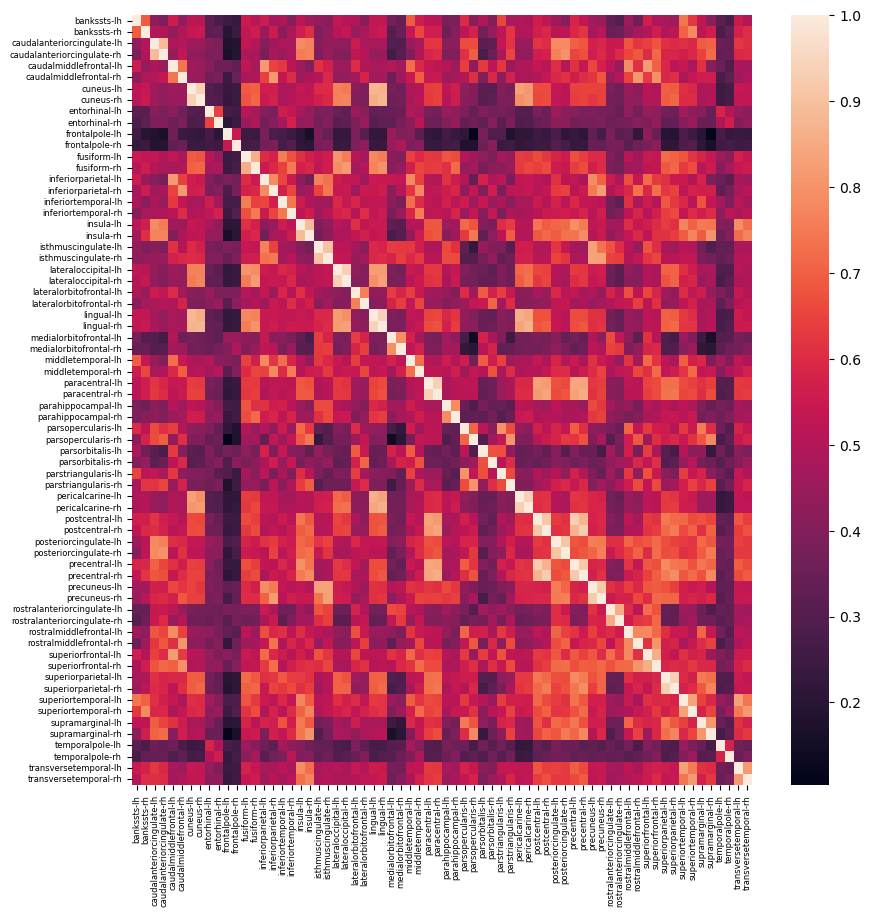

In [38]:
plt.figure(figsize = (10, 10))
img = sns.heatmap(FC_matrices, xticklabels = labels, yticklabels = labels)

plt.yticks(fontsize=6);
plt.xticks(fontsize=6);